<a href="https://colab.research.google.com/github/opaiot/ia-otimizacao-iot-industrias-negocios-public/blob/feature%2Fsync-colab/M1/colab/M1_Aulas_1_5_Aplica%C3%A7%C3%A3o_Pr%C3%A1tica_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

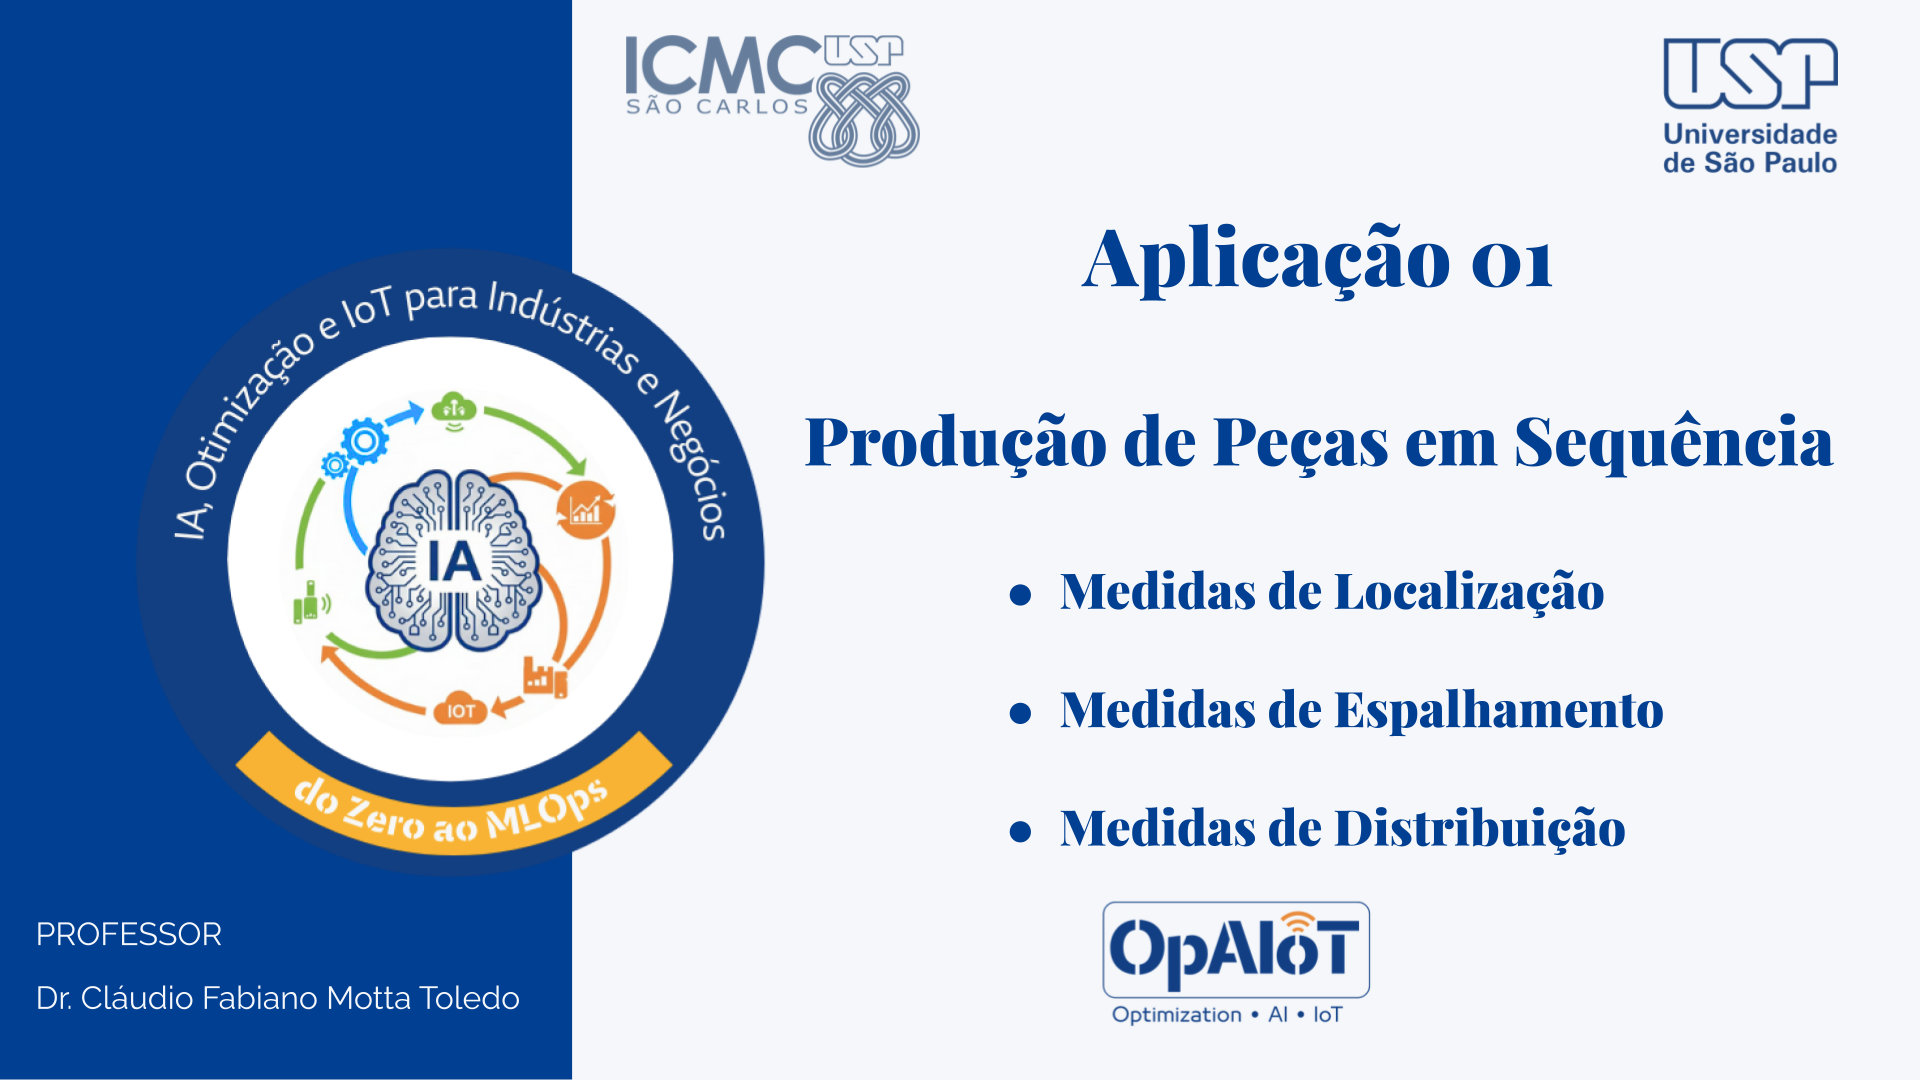


# Aula prática — Estatística descritiva e visualização multivariada com Pandas

A proposta é usar uma base sintética, simples e contextualizada, para praticar:

1. **Medidas de localização**: média, moda, quantis e percentis.
2. **Medidas de espalhamento**: intervalo, variância, desvio padrão e IQR.
3. **Medidas de distribuição**: obliquidade e curtose.
4. **Visualização multivariada**: heatmap de correlação e scatter plot.

A ideia central é aprender a responder perguntas como:

- Qual é o valor típico de uma variável do processo?
- Quão dispersos estão os dados?
- Há valores extremos?
- Algumas variáveis parecem se relacionar com a taxa de defeitos?



## 1. Contexto industrial da base sintética

Imagine uma linha industrial de produção com máquinas que fabricam peças em sequência. Em cada período de produção, sensores registram condições do processo, como temperatura, pressão, vibração e velocidade da esteira.

O objetivo da equipe de engenharia é acompanhar a **taxa de defeitos (%)** e investigar se ela está associada a variáveis do processo.



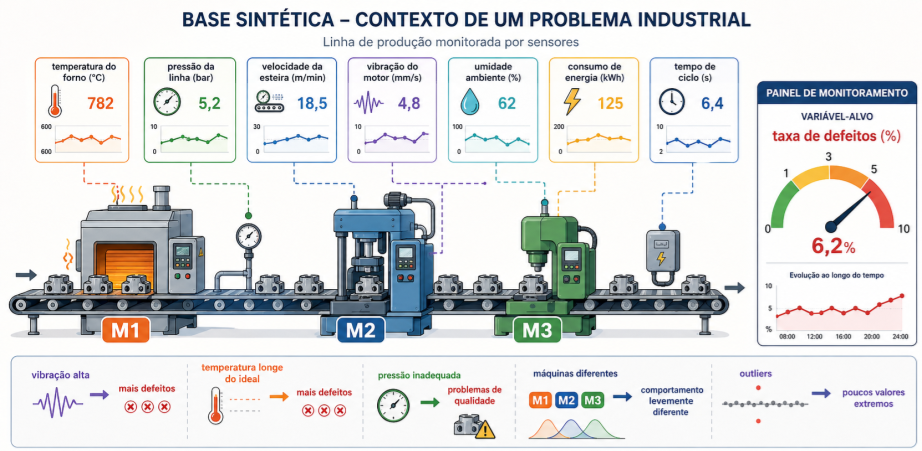


## 2. Bibliotecas usadas

Na próxima célula, vamos importar as bibliotecas principais:

- `numpy`: usado para gerar números aleatórios e fazer cálculos numéricos.
- `pandas`: usado para criar, salvar, ler e analisar tabelas de dados.
- `matplotlib.pyplot`: usado para criar gráficos.
- `seaborn`: usado para criar gráficos estatísticos com uma sintaxe mais simples, como `heatmap` e `scatterplot`.
  * https://seaborn.pydata.org/

Também ajustamos algumas opções de exibição do Pandas para deixar as tabelas mais legíveis no Colab.


In [ ]:

# ------------------------------------------------------------
# 1) Importação das bibliotecas
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações simples para melhorar a visualização das tabelas no Colab
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)

# Configuração visual padrão dos gráficos do seaborn
sns.set_theme(style="whitegrid")

print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!



## 3. Geração da base sintética e salvamento em CSV

A base é **sintética**, isto é, foi criada artificialmente para fins didáticos. Mesmo assim, ela foi construída para imitar padrões plausíveis de uma linha industrial:

- vibração alta tende a aumentar defeitos;
- temperatura distante do valor ideal tende a aumentar defeitos;
- pressão inadequada pode estar associada a problemas de qualidade;
- máquinas diferentes podem ter comportamentos levemente diferentes;
- alguns poucos valores extremos foram adicionados para mostrar o efeito de outliers.

#### Atributos da base

| Atributo | Tipo | Significado |
|---|---|---|
| `data` | Data | Dia da coleta |
| `turno` | Categórico | Turno de produção: manhã, tarde ou noite |
| `maquina` | Categórico | Máquina usada: M1, M2 ou M3 |
| `temperatura_forno_c` | Numérico | Temperatura do forno em graus Celsius |
| `pressao_linha_bar` | Numérico | Pressão da linha em bar |
| `velocidade_esteira_m_min` | Numérico | Velocidade da esteira em metros por minuto |
| `vibracao_motor_mm_s` | Numérico | Vibração do motor em mm/s |
| `umidade_ambiente_pct` | Numérico | Umidade ambiente em percentual |
| `consumo_energia_kwh` | Numérico | Consumo de energia em kWh no período |
| `tempo_ciclo_s` | Numérico | Tempo médio de ciclo em segundos |
| `taxa_defeitos_pct` | Numérico | Percentual de peças defeituosas no período |


####Principais recursos usados:

- `np.random.default_rng(42)`: cria um gerador de números aleatórios. O número `42` é uma semente que permite reproduzir os mesmos dados em outra execução.
- `rng.normal(loc, scale, size)`: gera valores seguindo uma distribuição normal.  
  - `loc` representa a média aproximada;
  - `scale` representa o desvio padrão aproximado;
  - `size` representa a quantidade de valores.
- `rng.choice(lista, size, p)`: sorteia categorias, como turno e máquina.
- `pd.DataFrame({...})`: cria uma tabela do Pandas.
- `df.to_csv("arquivo.csv", index=False)`: salva a tabela em um arquivo CSV.  
  - `index=False` evita salvar o índice do Pandas como uma coluna extra.

Ao final, o arquivo `dados_linha_producao.csv` ficará salvo no ambiente do Colab e poderá ser lido com `pd.read_csv()`.


In [ ]:

# ------------------------------------------------------------
# 2) Geração de uma base sintética industrial
# ------------------------------------------------------------

# Criamos um gerador de números aleatórios.
# A semente 42 ajuda a obter sempre os mesmos resultados.
rng = np.random.default_rng(42)

# Quantidade de registros da base
n = 600

# Datas de coleta: 600 períodos distribuídos a partir de uma data inicial
datas = pd.date_range(start="2026-01-01", periods=n, freq="H")

# Variáveis categóricas: turno e máquina
turnos = rng.choice(["Manhã", "Tarde", "Noite"], size=n, p=[0.38, 0.34, 0.28])
maquinas = rng.choice(["M1", "M2", "M3"], size=n, p=[0.40, 0.35, 0.25])

# Ajustes leves por máquina para criar diferenças realistas entre elas
ajuste_temp_maquina = np.where(maquinas == "M1", -1.0, np.where(maquinas == "M2", 0.5, 1.5))
ajuste_vibracao_maquina = np.where(maquinas == "M1", -0.2, np.where(maquinas == "M2", 0.1, 0.5))

# Sensores do processo
temperatura_forno_c = rng.normal(loc=180, scale=5, size=n) + ajuste_temp_maquina
pressao_linha_bar = rng.normal(loc=6.0, scale=0.45, size=n)
velocidade_esteira_m_min = rng.normal(loc=32, scale=3.2, size=n)
vibracao_motor_mm_s = rng.normal(loc=3.0, scale=0.7, size=n) + ajuste_vibracao_maquina
umidade_ambiente_pct = rng.normal(loc=55, scale=9, size=n)
tempo_ciclo_s = rng.normal(loc=42, scale=4.0, size=n)

# Evita alguns valores fisicamente pouco plausíveis
pressao_linha_bar = np.clip(pressao_linha_bar, 4.5, 7.5)
velocidade_esteira_m_min = np.clip(velocidade_esteira_m_min, 20, 45)
vibracao_motor_mm_s = np.clip(vibracao_motor_mm_s, 1.0, 7.0)
umidade_ambiente_pct = np.clip(umidade_ambiente_pct, 25, 85)
tempo_ciclo_s = np.clip(tempo_ciclo_s, 30, 60)

# Consumo de energia: depende um pouco da temperatura, velocidade e tempo de ciclo
consumo_energia_kwh = (
    55
    + 0.18 * (temperatura_forno_c - 180)
    + 0.55 * velocidade_esteira_m_min
    + 0.25 * tempo_ciclo_s
    + rng.normal(0, 3.0, size=n)
)

# A taxa de defeitos é construída para depender de alguns fatores do processo.
# Quanto maior a vibração e quanto mais a temperatura se afasta de 180 °C, maior tende a ser a taxa de defeitos.
desvio_temperatura = np.abs(temperatura_forno_c - 180)

taxa_defeitos_pct = (
    2.0
    + 0.65 * vibracao_motor_mm_s
    + 0.22 * desvio_temperatura
    + 0.35 * np.maximum(0, 5.8 - pressao_linha_bar)
    + 0.03 * umidade_ambiente_pct
    + rng.normal(0, 1.1, size=n)
)

# Garante que a taxa de defeitos fique em um intervalo razoável
taxa_defeitos_pct = np.clip(taxa_defeitos_pct, 0.2, 18)

# Inserimos alguns poucos valores extremos para discutir outliers.
# Exemplo: vibração muito alta em alguns períodos pode elevar defeitos.
indices_outliers = rng.choice(np.arange(n), size=8, replace=False)
vibracao_motor_mm_s[indices_outliers] += rng.normal(2.5, 0.4, size=8)
taxa_defeitos_pct[indices_outliers] += rng.normal(5.0, 1.0, size=8)

vibracao_motor_mm_s = np.clip(vibracao_motor_mm_s, 1.0, 9.5)
taxa_defeitos_pct = np.clip(taxa_defeitos_pct, 0.2, 25)

# Criação do DataFrame
df = pd.DataFrame({
    "data": datas,
    "turno": turnos,
    "maquina": maquinas,
    "temperatura_forno_c": temperatura_forno_c,
    "pressao_linha_bar": pressao_linha_bar,
    "velocidade_esteira_m_min": velocidade_esteira_m_min,
    "vibracao_motor_mm_s": vibracao_motor_mm_s,
    "umidade_ambiente_pct": umidade_ambiente_pct,
    "consumo_energia_kwh": consumo_energia_kwh,
    "tempo_ciclo_s": tempo_ciclo_s,
    "taxa_defeitos_pct": taxa_defeitos_pct,
})

# Arredondamos os valores para deixar a tabela mais parecida com dados medidos por sensores.
colunas_numericas = df.select_dtypes(include="number").columns
df[colunas_numericas] = df[colunas_numericas].round(2)

# Salvamento em CSV.
# No Colab, o arquivo será criado no ambiente atual.
nome_arquivo = "dados_linha_producao.csv"
df.to_csv(nome_arquivo, index=False)

print(f"Arquivo salvo com sucesso: {nome_arquivo}")
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

display(df.head())


Arquivo salvo com sucesso: dados_linha_producao.csv
Quantidade de linhas: 600
Quantidade de colunas: 11


/tmp/ipykernel_8639/3569744147.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  datas = pd.date_range(start="2026-01-01", periods=n, freq="H")


,data,turno,maquina,temperatura_forno_c,pressao_linha_bar,velocidade_esteira_m_min,vibracao_motor_mm_s,umidade_ambiente_pct,consumo_energia_kwh,tempo_ciclo_s,taxa_defeitos_pct
0,2026-01-01 00:00:00,Noite,M2,175.57,5.53,40.10,3.12,67.43,90.15,41.10,7.44
1,2026-01-01 01:00:00,Tarde,M3,177.20,5.94,36.74,2.38,70.09,86.61,43.22,8.46
2,2026-01-01 02:00:00,Noite,M3,193.79,5.45,35.58,4.49,61.46,83.45,37.45,9.31
3,2026-01-01 03:00:00,Tarde,M2,189.51,6.38,30.76,2.62,44.29,86.28,37.90,9.12
4,2026-01-01 04:00:00,Manhã,M3,179.44,5.59,29.17,4.92,59.42,76.86,41.62,7.19



### Interpretação da geração da base

A tabela exibida acima mostra as primeiras linhas da base sintética. Cada linha representa um período de operação da linha industrial.

Neste momento, o ponto mais importante é observar que temos:

- variáveis **categóricas**, como `turno` e `maquina`;
- variáveis **numéricas**, como temperatura, pressão, vibração e taxa de defeitos;
- uma variável de interesse para análise de qualidade: `taxa_defeitos_pct`.

Agora vamos simular o fluxo comum de trabalho em ciência de dados: ler o arquivo CSV a partir do disco.



## 4. Leitura da base

Nesta célula, vamos ler o arquivo CSV que acabamos de salvar.

Principais recursos usados:

- `pd.read_csv("arquivo.csv")`: lê um arquivo CSV e transforma os dados em um `DataFrame`.
  * Tabela separada por tabulação: pd.read_table("dados.tsv")
  * Excel: pd.read_excel()	pd.read_excel("dados.xlsx")
  * JSON	pd.read_json()	pd.read_json("dados.json")
  * HTML	pd.read_html()	pd.read_html("pagina.html")
  * muitos outros, consulte a documentação:
    * https://pandas.pydata.org/docs/reference/api/pandas.read_table.html
- `.head()`: mostra as primeiras linhas da tabela.
- `.shape`: mostra a quantidade de linhas e colunas.
- `.info()`: mostra tipos das colunas e quantidade de valores não nulos.
- `.describe()`: gera estatísticas descritivas iniciais das variáveis numéricas.

Esses comandos são muito úteis no início de qualquer análise de dados.


In [ ]:

# ------------------------------------------------------------
# 3) Leitura do arquivo CSV
# ------------------------------------------------------------

dados = pd.read_csv("dados_linha_producao.csv")

print("Dimensões da base:")
print(dados.shape)

print("\nPrimeiras linhas:")
display(dados.head())

print("\nInformações gerais:")
dados.info()

print("\nResumo estatístico inicial:")
display(dados.describe())


Dimensões da base:
(600, 11)

Primeiras linhas:


,data,turno,maquina,temperatura_forno_c,pressao_linha_bar,velocidade_esteira_m_min,vibracao_motor_mm_s,umidade_ambiente_pct,consumo_energia_kwh,tempo_ciclo_s,taxa_defeitos_pct
0,2026-01-01 00:00:00,Noite,M2,175.57,5.53,40.10,3.12,67.43,90.15,41.10,7.44
1,2026-01-01 01:00:00,Tarde,M3,177.20,5.94,36.74,2.38,70.09,86.61,43.22,8.46
2,2026-01-01 02:00:00,Noite,M3,193.79,5.45,35.58,4.49,61.46,83.45,37.45,9.31
3,2026-01-01 03:00:00,Tarde,M2,189.51,6.38,30.76,2.62,44.29,86.28,37.90,9.12
4,2026-01-01 04:00:00,Manhã,M3,179.44,5.59,29.17,4.92,59.42,76.86,41.62,7.19



Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   data                      600 non-null    object 
 1   turno                     600 non-null    object 
 2   maquina                   600 non-null    object 
 3   temperatura_forno_c       600 non-null    float64
 4   pressao_linha_bar         600 non-null    float64
 5   velocidade_esteira_m_min  600 non-null    float64
 6   vibracao_motor_mm_s       600 non-null    float64
 7   umidade_ambiente_pct      600 non-null    float64
 8   consumo_energia_kwh       600 non-null    float64
 9   tempo_ciclo_s             600 non-null    float64
 10  taxa_defeitos_pct         600 non-null    float64
dtypes: float64(8), object(3)
memory usage: 51.7+ KB

Resumo estatístico inicial:


,temperatura_forno_c,pressao_linha_bar,velocidade_esteira_m_min,vibracao_motor_mm_s,umidade_ambiente_pct,consumo_energia_kwh,tempo_ciclo_s,taxa_defeitos_pct
count,600.000,600.000,600.000,600.000,600.000,600.000,600.000,600.000
mean,179.801,5.980,32.052,3.144,54.889,83.003,42.003,6.792
std,5.386,0.453,3.260,0.761,8.892,3.820,4.030,1.587
min,164.220,4.620,22.840,1.000,31.370,70.000,30.000,1.860
25%,176.120,5.670,29.837,2.627,48.677,80.487,39.258,5.700
50%,179.905,6.015,31.990,3.120,54.475,82.955,42.035,6.755
75%,183.297,6.270,34.425,3.600,60.440,85.655,44.405,7.723
max,193.790,7.290,41.790,6.810,85.000,94.710,55.080,15.030



### Interpretação inicial

A saída de `.shape` informa o tamanho da base. Neste exemplo, temos 600 linhas, isto é, 600 registros de operação da linha industrial.

A saída de `.info()` ajuda a verificar se as colunas foram lidas corretamente. Por exemplo:

- `object` normalmente representa texto ou categorias;
- `float64` representa números com casas decimais;
- `int64` representa números inteiros.

A saída de `.describe()` já apresenta algumas medidas importantes, como média, desvio padrão, mínimo, máximo e quartis. Nas próximas seções, vamos estudar essas medidas com mais calma.



## 5. Seleção de variáveis numéricas

Muitas medidas estatísticas, como média, variância e desvio padrão, fazem sentido para variáveis numéricas.

Nesta célula, vamos criar uma lista chamada `colunas_numericas`.

Principais recursos usados:

- `.select_dtypes(include="number")`: seleciona somente colunas numéricas, ou seja retorna um DataFrame contendo apenas as colunas numéricas.
- `.columns`: retorna os nomes das colunas.
- `list(...)`: transforma o resultado em uma lista Python.

Essa lista será reutilizada nas próximas análises.


In [ ]:

# ------------------------------------------------------------
# 4) Seleção das colunas numéricas
# ------------------------------------------------------------

colunas_numericas = list(dados.select_dtypes(include="number").columns)

print("Colunas numéricas da base:")
print(colunas_numericas)


Colunas numéricas da base:
['temperatura_forno_c', 'pressao_linha_bar', 'velocidade_esteira_m_min', 'vibracao_motor_mm_s', 'umidade_ambiente_pct', 'consumo_energia_kwh', 'tempo_ciclo_s', 'taxa_defeitos_pct']



## 6. Medidas de localização

Medidas de localização ajudam a responder:

> “Qual é um valor típico ou representativo desta variável?”

Nesta seção, vamos usar:

- **Média**: soma dos valores dividida pela quantidade de observações.
- **Moda**: valor mais frequente.
- **Quantil**: ponto que divide os dados ordenados em partes.
- **Percentil**: um caso particular de quantil, usando escala de 0 a 100.

No Pandas, os métodos principais são:

- `.mean()`: calcula a média.
- `.mode()`: calcula a moda.
- `.quantile(q)`: calcula o quantil.
  - `q=0.25` representa o primeiro quartil, ou percentil 25;
  - `q=0.50` representa a mediana, ou percentil 50;
  - `q=0.75` representa o terceiro quartil, ou percentil 75.


In [ ]:

# ------------------------------------------------------------
# 5) Medidas de localização para uma variável de interesse
# ------------------------------------------------------------

# Vamos começar pela taxa de defeitos, pois ela representa a qualidade do processo.
variavel = "taxa_defeitos_pct"

media = dados[variavel].mean()
moda = dados[variavel].mode()
q25 = dados[variavel].quantile(0.25)
q50 = dados[variavel].quantile(0.50)  # também é a mediana
q75 = dados[variavel].quantile(0.75)
p90 = dados[variavel].quantile(0.90)  # percentil 90

resumo_localizacao = pd.DataFrame({
    "metrica": ["Média", "Moda", "Q25 / Percentil 25", "Q50 / Mediana", "Q75 / Percentil 75", "P90 / Percentil 90"],
    "valor": [
        media,
        moda.iloc[0],  # usamos iloc[0] para pegar a primeira moda, caso exista mais de uma
        q25,
        q50,
        q75,
        p90
    ]
})

display(resumo_localizacao)


,metrica,valor
0,Média,6.792
1,Moda,5.640
2,Q25 / Percentil 25,5.700
3,Q50 / Mediana,6.755
4,Q75 / Percentil 75,7.723
5,P90 / Percentil 90,8.615



### Interpretação das medidas de localização

A média resume a taxa de defeitos em um único valor. Ela é útil, mas pode ser influenciada por valores extremos.

A mediana, representada por `Q50`, indica o ponto central da distribuição: metade dos registros tem taxa de defeitos abaixo desse valor e metade acima.

O percentil 90, `P90`, ajuda a responder uma pergunta prática:

> Em 90% dos períodos, a taxa de defeitos ficou até qual valor?

Esse tipo de medida é muito útil em processos industriais, pois ajuda a definir limites de alerta e metas de controle.



## 7. Moda em variáveis categóricas

A moda é especialmente útil para variáveis categóricas.

Por exemplo:

- Qual turno aparece mais vezes na base?
- Qual máquina tem mais registros?
- Existe uma categoria dominante?

Nesta célula, vamos usar:

- `.mode()`: para obter a categoria mais frequente.
- `.value_counts()`: para contar quantas vezes cada categoria aparece.
- `normalize=True`: transforma as contagens em proporções.


In [ ]:

# ------------------------------------------------------------
# 6) Moda e frequência em variáveis categóricas
# ------------------------------------------------------------

for coluna in ["turno", "maquina"]:
    print(f"\nColuna: {coluna}")
    print(f"Moda: {dados[coluna].mode().iloc[0]}")
    #.iloc[0] significa: “pegue o primeiro elemento da Series retornada por .mode()

    frequencias = dados[coluna].value_counts()
    proporcoes = dados[coluna].value_counts(normalize=True) * 100

    tabela_freq = pd.DataFrame({
        "contagem": frequencias,
        "percentual": proporcoes.round(2)
    })

    display(tabela_freq)



Coluna: turno
Moda: Manhã


,contagem,percentual
turno,,
Manhã,229,38.17
Tarde,207,34.50
Noite,164,27.33



Coluna: maquina
Moda: M1


,contagem,percentual
maquina,,
M1,240,40.00
M2,199,33.17
M3,161,26.83



### Interpretação da moda em categorias

Para variáveis categóricas, a moda indica a categoria mais comum.

Se a máquina `M1`, por exemplo, aparecer mais vezes, isso não significa necessariamente que ela é melhor ou pior. Significa apenas que há mais registros dela na base.

Esse cuidado é importante: frequência de ocorrência não é o mesmo que desempenho. Para avaliar desempenho por máquina, seria necessário comparar também a taxa de defeitos, consumo, vibração e outras variáveis.



## 8. Quantis e percentis para várias variáveis

Agora vamos calcular percentis para todas as variáveis numéricas.

Principais recursos usados:

- `.quantile([0.05, 0.25, 0.50, 0.75, 0.95])`: calcula vários quantis de uma vez.
- `.T`: transpõe a tabela, trocando linhas por colunas.
- `.rename(columns={...})`: renomeia colunas para deixar o resultado mais legível.

Percentis úteis:

- `P05`: valor abaixo do qual estão 5% dos dados;
- `P25`: primeiro quartil;
- `P50`: mediana;
- `P75`: terceiro quartil;
- `P95`: valor abaixo do qual estão 95% dos dados.


In [ ]:

# ------------------------------------------------------------
# 7) Quantis e percentis para todas as variáveis numéricas
# ------------------------------------------------------------

percentis = dados[colunas_numericas].quantile([0.05, 0.25, 0.50, 0.75, 0.95]).T
#DataFrame resultante fica com essas probabilidades como nomes das colunas.

percentis = percentis.rename(columns={
    0.05: "P05", #Coluna 0.05 é renomeada para "P05"
    0.25: "P25",
    0.50: "P50_mediana",
    0.75: "P75",
    0.95: "P95"
})

display(percentis)


,P05,P25,P50_mediana,P75,P95
temperatura_forno_c,171.117,176.120,179.905,183.297,189.021
pressao_linha_bar,5.190,5.670,6.015,6.270,6.700
velocidade_esteira_m_min,26.378,29.837,31.990,34.425,37.251
vibracao_motor_mm_s,1.960,2.627,3.120,3.600,4.391
umidade_ambiente_pct,40.648,48.677,54.475,60.440,69.980
consumo_energia_kwh,76.579,80.487,82.955,85.655,89.311
tempo_ciclo_s,35.437,39.258,42.035,44.405,48.771
taxa_defeitos_pct,4.470,5.700,6.755,7.723,9.311



### Interpretação dos percentis

Percentis são úteis para interpretar extremos de forma mais robusta do que olhar apenas mínimo e máximo.

Por exemplo, o `P95` da vibração indica um limite que somente cerca de 5% dos registros ultrapassam. Em aplicações industriais, esse valor pode ser usado como referência para investigar condições anormais.

O `P50`, ou mediana, ajuda a representar o centro da variável sem sofrer tanto com valores extremos.



## 9. Visualização de localização: histograma com média e mediana

Um histograma mostra como os valores estão distribuídos.

Nesta célula, vamos representar a distribuição da `taxa_defeitos_pct` e adicionar duas linhas:

- linha da média;
- linha da mediana.

Principais recursos usados:

- `sns.histplot(...)`: cria histograma.
- `kde=True`: adiciona uma curva suavizada da distribuição.
- `plt.axvline(...)`: adiciona uma linha vertical.
- `plt.legend()`: exibe a legenda.


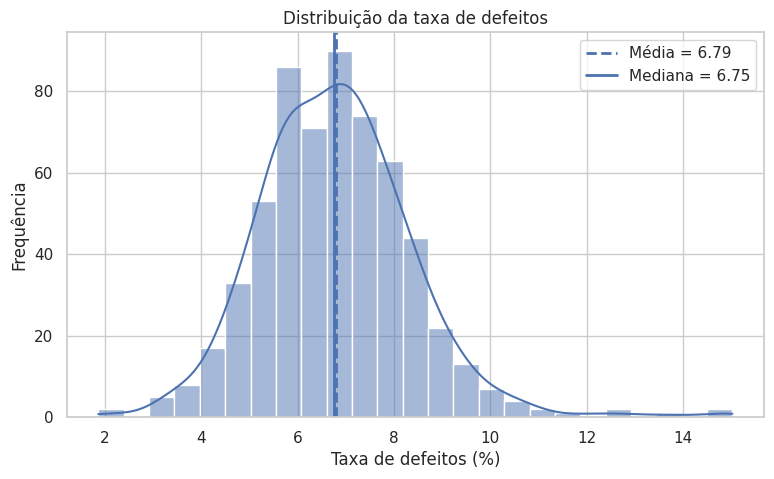

In [ ]:

# ------------------------------------------------------------
# 8) Histograma com média e mediana
# ------------------------------------------------------------

variavel = "taxa_defeitos_pct"

media = dados[variavel].mean()
mediana = dados[variavel].median()

plt.figure(figsize=(9, 5))
sns.histplot(data=dados, x=variavel, bins=25, kde=True)

plt.axvline(media, linestyle="--", linewidth=2, label=f"Média = {media:.2f}")
plt.axvline(mediana, linestyle="-", linewidth=2, label=f"Mediana = {mediana:.2f}")

plt.title("Distribuição da taxa de defeitos")
plt.xlabel("Taxa de defeitos (%)")
plt.ylabel("Frequência")
plt.legend()
plt.show()



### Interpretação do histograma

Se a média ficar muito distante da mediana, isso pode indicar assimetria ou presença de valores extremos.

No contexto industrial, uma cauda à direita na taxa de defeitos significa que a maioria dos períodos tem defeitos moderados, mas alguns períodos apresentam valores bem mais altos. Esses períodos merecem investigação.



## 10. Medidas de espalhamento

Medidas de espalhamento ajudam a responder:

> “Os valores estão concentrados ou muito dispersos?”

Nesta seção, vamos calcular:

- **Intervalo**: máximo menos mínimo.
- **Variância**: média dos desvios quadráticos em relação à média.
- **Desvio padrão**: raiz quadrada da variância; fica na mesma unidade da variável.
- **IQR**: intervalo interquartil, calculado como `Q75 - Q25`.

No Pandas:

- `.min()` calcula o mínimo;
- `.max()` calcula o máximo;
- `.var()` calcula a variância;
- `.std()` calcula o desvio padrão;
- `.quantile(0.75) - .quantile(0.25)` calcula o IQR.


In [ ]:

# ------------------------------------------------------------
# 9) Medidas de espalhamento
# ------------------------------------------------------------

resumo_espalhamento = pd.DataFrame(index=colunas_numericas)

resumo_espalhamento["minimo"] = dados[colunas_numericas].min()
resumo_espalhamento["maximo"] = dados[colunas_numericas].max()
resumo_espalhamento["intervalo"] = resumo_espalhamento["maximo"] - resumo_espalhamento["minimo"]

# Por padrão, o Pandas calcula variância e desvio padrão amostrais, usando ddof=1.
resumo_espalhamento["variancia"] = dados[colunas_numericas].var()
resumo_espalhamento["desvio_padrao"] = dados[colunas_numericas].std()
means= dados[colunas_numericas].mean()
stds = dados[colunas_numericas].std()
resumo_espalhamento["media+-dp"]=[f'{m:.2f}+-{s:.2f}' for m,s in zip(means,stds)]

q25 = dados[colunas_numericas].quantile(0.25)
q75 = dados[colunas_numericas].quantile(0.75)
resumo_espalhamento["IQR"] = q75 - q25

display(resumo_espalhamento.round(3))


,minimo,maximo,intervalo,variancia,desvio_padrao,media+-dp,IQR
temperatura_forno_c,164.22,193.79,29.57,29.005,5.386,179.80+-5.39,7.177
pressao_linha_bar,4.62,7.29,2.67,0.205,0.453,5.98+-0.45,0.600
velocidade_esteira_m_min,22.84,41.79,18.95,10.631,3.260,32.05+-3.26,4.587
vibracao_motor_mm_s,1.00,6.81,5.81,0.578,0.761,3.14+-0.76,0.973
umidade_ambiente_pct,31.37,85.00,53.63,79.063,8.892,54.89+-8.89,11.763
consumo_energia_kwh,70.00,94.71,24.71,14.593,3.820,83.00+-3.82,5.168
tempo_ciclo_s,30.00,55.08,25.08,16.241,4.030,42.00+-4.03,5.148
taxa_defeitos_pct,1.86,15.03,13.17,2.519,1.587,6.79+-1.59,2.022



### Interpretação das medidas de espalhamento

O intervalo mostra a amplitude total da variável, mas pode ser muito influenciado por valores extremos.

O desvio padrão mostra uma dispersão típica em torno da média. Por estar na mesma unidade da variável, costuma ser mais fácil de interpretar do que a variância.

O IQR mede a dispersão dos 50% centrais dos dados. Por ignorar as caudas, ele é mais robusto a outliers do que o intervalo.



## 11. Boxplot para visualizar espalhamento e possíveis outliers

O boxplot é uma visualização muito útil para analisar dispersão.

Ele mostra:

- mediana;
- primeiro quartil `Q25`;
- terceiro quartil `Q75`;
- intervalo interquartil `IQR`;
- possíveis valores extremos.

Nesta célula, vamos criar boxplots para algumas variáveis importantes do processo.


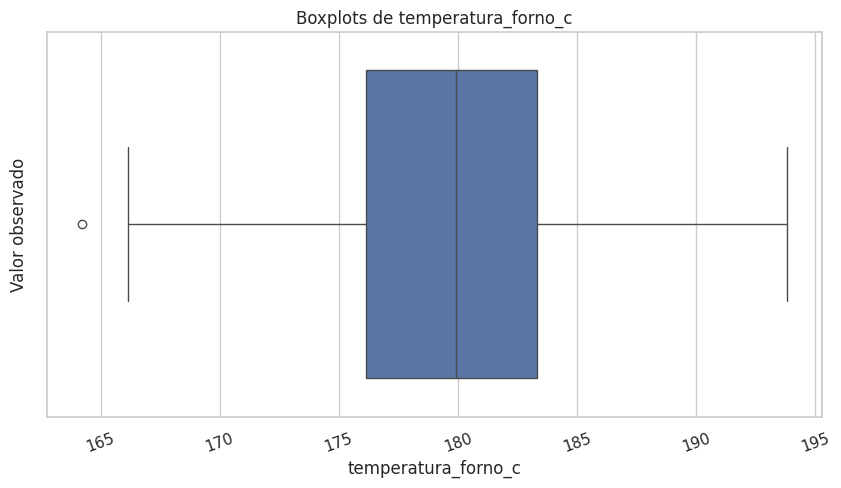

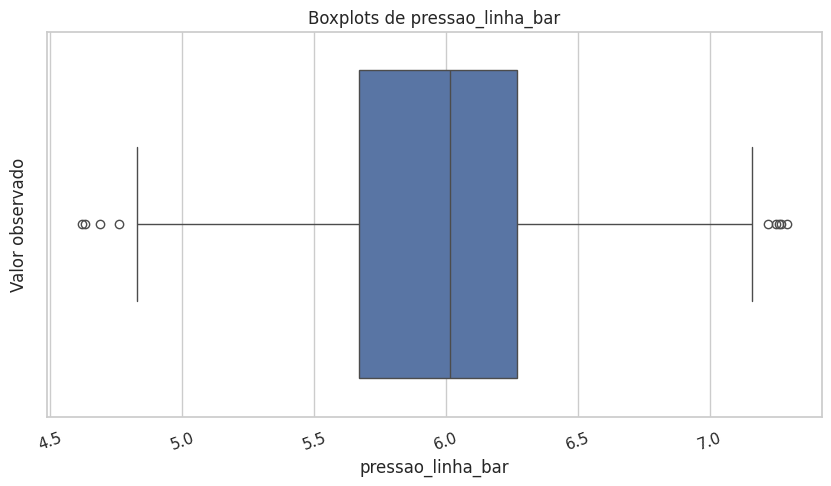

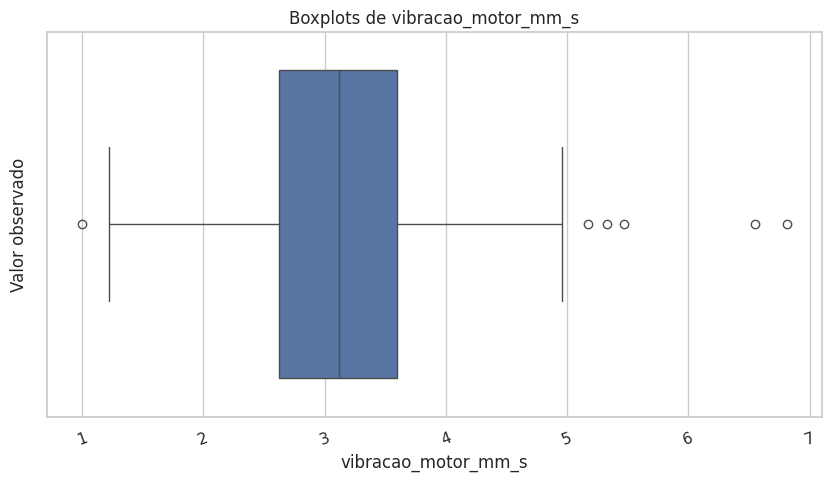

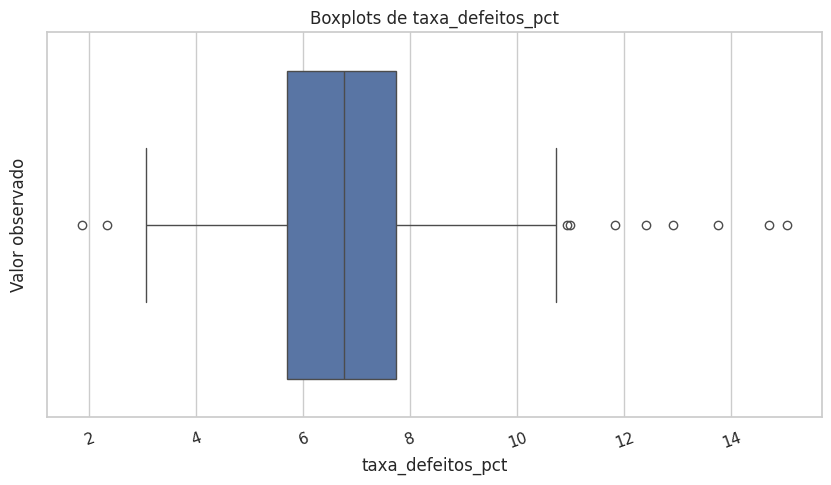

In [ ]:

# ------------------------------------------------------------
# 10) Boxplots de variáveis selecionadas
# ------------------------------------------------------------

variaveis_boxplot = [
    "temperatura_forno_c",
    "pressao_linha_bar",
    "vibracao_motor_mm_s",
    "taxa_defeitos_pct"
]

for var in variaveis_boxplot:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=dados, x=var)
    plt.title(f"Boxplots de {var}")
    plt.xlabel(var)
    plt.ylabel("Valor observado")
    plt.xticks(rotation=20)
    plt.show()



### Interpretação do boxplot

Variáveis com caixas maiores apresentam maior dispersão nos 50% centrais dos dados.

Pontos muito afastados podem indicar valores extremos. No caso de vibração e taxa de defeitos, esses pontos podem representar períodos com condições anormais de operação.

Na prática, outliers não devem ser removidos automaticamente. Primeiro, é importante investigar se eles representam erro de medição ou eventos reais do processo.



## 12. Medidas de distribuição: obliquidade e curtose

Além de localização e espalhamento, podemos analisar o formato da distribuição.

### Obliquidade

A obliquidade mede a assimetria da distribuição.

- Valor próximo de 0: distribuição mais simétrica.
- Valor positivo: cauda mais longa à direita.
- Valor negativo: cauda mais longa à esquerda.

No Pandas, usamos:

- `.skew()`

### Curtose

A curtose ajuda a avaliar o peso das caudas e a presença de valores extremos.

No Pandas, usamos:

- `.kurt()`

Importante: o Pandas retorna a **curtose excessiva**. Nessa convenção, uma distribuição normal tem curtose próxima de 0. Na definição clássica, a normal teria curtose próxima de 3.


In [ ]:

# ------------------------------------------------------------
# 11) Obliquidade e curtose
# ------------------------------------------------------------

resumo_distribuicao = pd.DataFrame({
    "obliquidade_skew": dados[colunas_numericas].skew(),
    "curtose_excessiva_kurt": dados[colunas_numericas].kurt()
})

display(resumo_distribuicao.round(3))


,obliquidade_skew,curtose_excessiva_kurt
temperatura_forno_c,0.006,-0.134
pressao_linha_bar,-0.083,0.192
velocidade_esteira_m_min,-0.026,-0.233
vibracao_motor_mm_s,0.433,1.146
umidade_ambiente_pct,0.203,0.062
consumo_energia_kwh,0.005,-0.065
tempo_ciclo_s,0.002,0.266
taxa_defeitos_pct,0.762,2.802



### Interpretação de obliquidade e curtose

| Variável                   | Obliquidade | Curtose excessiva | Interpretação                                                                                                                                                                |
| -------------------------- | ----------: | ----------------: | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `temperatura_forno_c`      |     `0.006` |          `-0.134` | Praticamente simétrica, com curtose muito  <br/>próxima de zero.Distribuição próxima da normal,  <br/>levemente mais achatada.                                                          |
| `pressao_linha_bar`        |    `-0.083` |           `0.192` | Quase simétrica, com leve cauda à esquerda. <br/>Curtose próxima de zero, indicando comportamento  <br/>próximo ao normal.                                                              |
| `velocidade_esteira_m_min` |    `-0.026` |          `-0.233` | Praticamente simétrica. Curtose negativa leve, sugerindo  <br/>distribuição um pouco mais achatada e com caudas mais leves.                                                        |
| `vibracao_motor_mm_s`      |     `0.433` |           `1.146` | Assimetria positiva moderada. Há tendência de alguns  <br/>valores mais altos de vibração. Curtose positiva indica  <br/>caudas mais pesadas, sugerindo presença de valores extremos.    |
| `umidade_ambiente_pct`     |     `0.203` |           `0.062` | Leve assimetria à direita. Curtose praticamente nula, <br/> distribuição próxima da normal.                                                                                        |
| `consumo_energia_kwh`      |     `0.005` |          `-0.065` | Quase perfeitamente simétrica. Curtose muito próxima de zero,  <br/>comportamento bastante próximo ao normal.                                                                      |
| `tempo_ciclo_s`            |     `0.002` |           `0.266` | Praticamente simétrica. Curtose levemente positiva, indicando  <br/>pequena tendência a caudas um pouco mais pesadas.                                                              |
| `taxa_defeitos_pct`        |     `0.762` |           `2.802` | Assimetria positiva mais forte. Curtose alta, indicando  <br/>caudas pesadas e maior presença de valores extremos.  <br/>É a variável com maior indício de outliers ou eventos anormais. |




## 13. Histogramas para observar o formato das distribuições

Agora vamos visualizar algumas distribuições para conectar os números de obliquidade e curtose com os gráficos.

Nesta célula, usamos:

- `plt.subplots(...)`: cria vários espaços de gráfico.
- `sns.histplot(...)`: cria histogramas.
- `for`: repete o mesmo procedimento para várias variáveis.

A repetição com `for` é útil porque evita copiar e colar código muitas vezes.


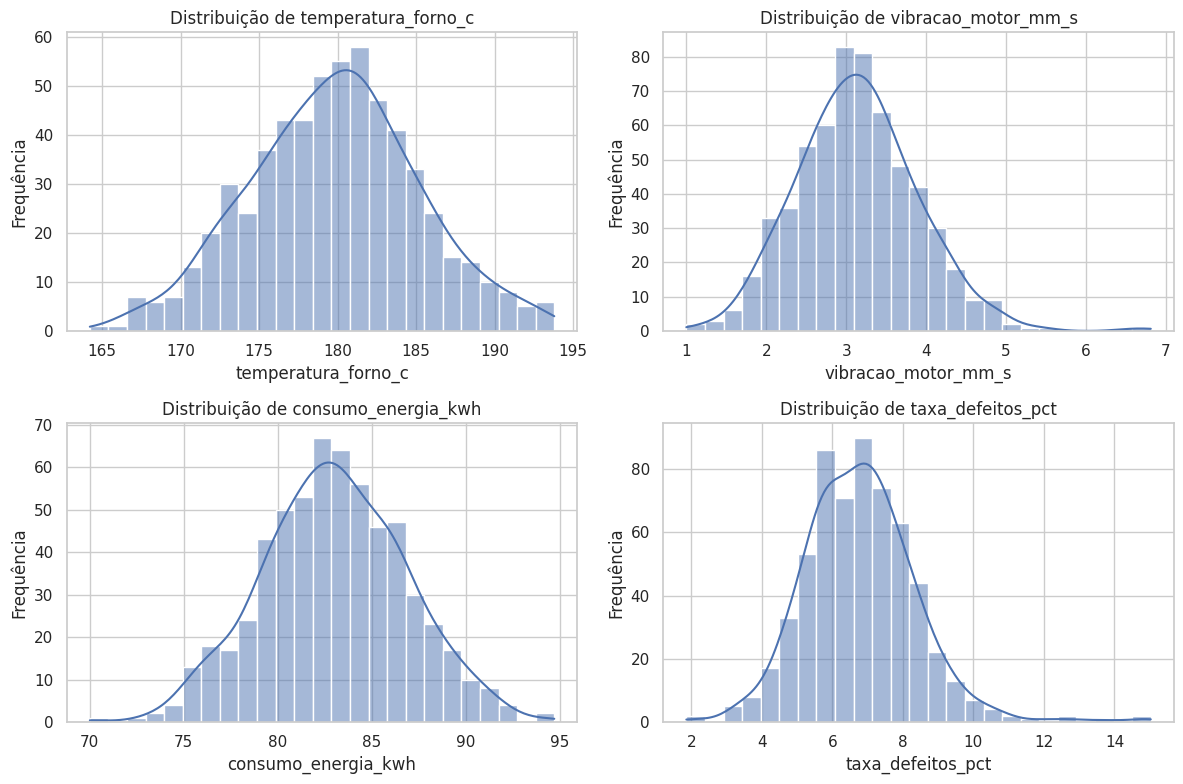

In [ ]:

# ------------------------------------------------------------
# 12) Histogramas de variáveis selecionadas
# ------------------------------------------------------------

variaveis_hist = [
    "temperatura_forno_c",
    "vibracao_motor_mm_s",
    "consumo_energia_kwh",
    "taxa_defeitos_pct"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()  # transforma a matriz de eixos em uma lista simples

for ax, variavel in zip(axes, variaveis_hist):
    sns.histplot(data=dados, x=variavel, bins=25, kde=True, ax=ax)
    ax.set_title(f"Distribuição de {variavel}")
    ax.set_xlabel(variavel)
    ax.set_ylabel("Frequência")

plt.tight_layout()
plt.show()



### Interpretação dos histogramas

Os histogramas ajudam a verificar visualmente se uma variável é aproximadamente simétrica ou se apresenta cauda para algum lado.

Quando a cauda aparece mais longa à direita, esperamos obliquidade positiva. Quando há poucos valores muito altos, a curtose excessiva também pode aumentar.

Esse tipo de análise é útil antes de aplicar modelos de aprendizado de máquina, pois variáveis com caudas muito longas ou muitos outliers podem exigir tratamento especial.



## 14. Análise multivariada com matriz de correlação

Até agora, analisamos variáveis principalmente de forma individual.

Na análise multivariada, começamos a estudar relações entre variáveis.

A correlação mede a força e a direção de uma relação linear entre duas variáveis numéricas.

- Correlação próxima de `1`: quando uma variável aumenta, a outra tende a aumentar.
- Correlação próxima de `-1`: quando uma variável aumenta, a outra tende a diminuir.
- Correlação próxima de `0`: não há relação linear clara.

No Pandas:

- `.corr()` calcula a matriz de correlação entre variáveis numéricas.

Atenção: correlação não implica causalidade. Ela sugere associação, mas não prova que uma variável causa a outra.


In [ ]:

# ------------------------------------------------------------
# 13) Matriz de correlação
# ------------------------------------------------------------

correlacao = dados[colunas_numericas].corr()

display(correlacao.round(2))


,temperatura_forno_c,pressao_linha_bar,velocidade_esteira_m_min,vibracao_motor_mm_s,umidade_ambiente_pct,consumo_energia_kwh,tempo_ciclo_s,taxa_defeitos_pct
temperatura_forno_c,1.00,-0.06,-0.01,0.06,0.04,0.23,-0.02,-0.08
pressao_linha_bar,-0.06,1.00,-0.03,-0.00,0.04,-0.05,-0.02,0.01
velocidade_esteira_m_min,-0.01,-0.03,1.00,0.02,0.01,0.50,-0.01,0.04
vibracao_motor_mm_s,0.06,-0.00,0.02,1.00,-0.01,0.05,0.05,0.37
umidade_ambiente_pct,0.04,0.04,0.01,-0.01,1.00,-0.03,-0.05,0.16
consumo_energia_kwh,0.23,-0.05,0.50,0.05,-0.03,1.00,0.27,-0.00
tempo_ciclo_s,-0.02,-0.02,-0.01,0.05,-0.05,0.27,1.00,0.02
taxa_defeitos_pct,-0.08,0.01,0.04,0.37,0.16,-0.00,0.02,1.00



## 15. Heatmap da matriz de correlação

O heatmap facilita a leitura visual da matriz de correlação.

Nesta célula, usamos:

- `sns.heatmap(...)`: cria o mapa de calor.
- `annot=True`: escreve os valores de correlação dentro das células.
- `fmt=".2f"`: mostra os valores com duas casas decimais.
- `cmap="coolwarm"`: usa uma escala de cores comum para correlação.
- `vmin=-1` e `vmax=1`: fixa a escala entre -1 e 1.


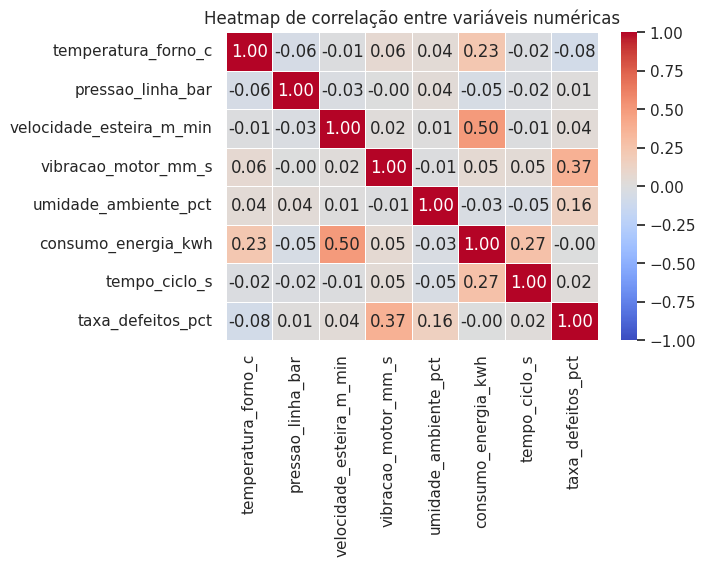

In [ ]:

# ------------------------------------------------------------
# 14) Heatmap da matriz de correlação
# ------------------------------------------------------------

plt.figure(figsize=(6, 4))
sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Heatmap de correlação entre variáveis numéricas")
plt.show()



### Interpretação do heatmap

Valores próximos de:

```text
 1  → correlação positiva forte
 0  → pouca ou nenhuma correlação linear
-1  → correlação negativa forte
```

## Principais correlações observadas

| Par de variáveis                                   | Correlação | Interpretação                                                                                                  |
| -------------------------------------------------- | ---------: | -------------------------------------------------------------------------------------------------------------- |
| `velocidade_esteira_m_min` × `consumo_energia_kwh` |     `0.50` | Correlação positiva moderada.<br> Quando a velocidade da esteira aumenta, <br>o consumo de energia tende a aumentar.   |
| `vibracao_motor_mm_s` × `taxa_defeitos_pct`        |     `0.37` | Correlação positiva fraca a moderada. <br>Maior vibração do motor parece estar associada <br>a maior taxa de defeitos. |
| `consumo_energia_kwh` × `tempo_ciclo_s`            |     `0.27` | Correlação positiva fraca. <br>Ciclos mais longos tendem a estar associados<br> a maior consumo de energia.            |
| `temperatura_forno_c` × `consumo_energia_kwh`      |     `0.23` | Correlação positiva fraca. <br>Temperaturas mais altas podem estar associadas <br> a maior consumo energético.          |
| `umidade_ambiente_pct` × `taxa_defeitos_pct`       |     `0.16` | Correlação positiva muito fraca. <br>Pode haver leve associação entre umidade e defeitos,<br> mas é pequena.           |

## Conclusão

O heatmap sugere que o processo tem poucas correlações lineares fortes. As relações mais importantes para investigação são:

1. **Velocidade da esteira e consumo de energia**: possível relação operacional direta.
2. **Vibração do motor e taxa de defeitos**: possível sinal de problema mecânico afetando a qualidade.
3. **Tempo de ciclo e consumo de energia**: ciclos mais longos podem aumentar o gasto energético.

Uma observação importante: **correlação não implica causalidade**. Por exemplo, maior vibração pode estar associada a mais defeitos, mas isso não prova que a vibração seja a causa direta. Para confirmar, seria necessário analisar o processo, fazer testes controlados ou treinar modelos preditivos com validação adequada.

Na prática, esse tipo de análise ajuda a formular hipóteses. Por exemplo:

> “Será que períodos com maior vibração apresentam maior taxa de defeitos?”

Essa hipótese pode ser investigada com scatter plots.



## 16. Criando uma variável derivada: desvio da temperatura ideal

Em processos industriais, muitas vezes o problema não é a temperatura ser simplesmente alta ou baixa, mas sim estar distante do valor ideal.

Neste exemplo, vamos assumir que a temperatura ideal do forno é 180 °C.

Vamos criar a variável:

`desvio_temperatura_c = |temperatura_forno_c - 180|`

Principais recursos usados:

- `np.abs(...)`: calcula valor absoluto.
- criação de nova coluna em Pandas usando `dados["nova_coluna"] = ...`.


In [ ]:

# ------------------------------------------------------------
# 15) Criação de variável derivada
# ------------------------------------------------------------

dados["desvio_temperatura_c"] = np.abs(dados["temperatura_forno_c"] - 180)

display(dados[["temperatura_forno_c", "desvio_temperatura_c", "taxa_defeitos_pct"]].head())

print("Correlação entre desvio de temperatura e taxa de defeitos:")
print(dados["desvio_temperatura_c"].corr(dados["taxa_defeitos_pct"]).round(3))


,temperatura_forno_c,desvio_temperatura_c,taxa_defeitos_pct
0,175.57,4.43,7.44
1,177.20,2.80,8.46
2,193.79,13.79,9.31
3,189.51,9.51,9.12
4,179.44,0.56,7.19


Correlação entre desvio de temperatura e taxa de defeitos:
0.487



### Interpretação da variável derivada

A nova coluna `desvio_temperatura_c` representa o quanto a temperatura se afastou do valor ideal.

Esse é um exemplo simples de **engenharia de atributos**. Em vez de usar apenas a temperatura original, criamos uma variável que faz mais sentido para o problema industrial.

Esse tipo de raciocínio é muito importante em aprendizado de máquina: bons atributos geralmente incorporam conhecimento do domínio.



## 17. Scatter plot: vibração versus taxa de defeitos

O scatter plot mostra a relação entre duas variáveis numéricas.

Nesta célula, vamos analisar:

- eixo X: `vibracao_motor_mm_s`;
- eixo Y: `taxa_defeitos_pct`;
- cor dos pontos: `turno`.

Principais recursos usados:

- `sns.scatterplot(...)`: cria gráfico de dispersão.
- `x=...`: variável no eixo horizontal.
- `y=...`: variável no eixo vertical.
- `hue=...`: variável usada para colorir os pontos.
- `alpha=0.7`: transparência dos pontos, útil quando há sobreposição.


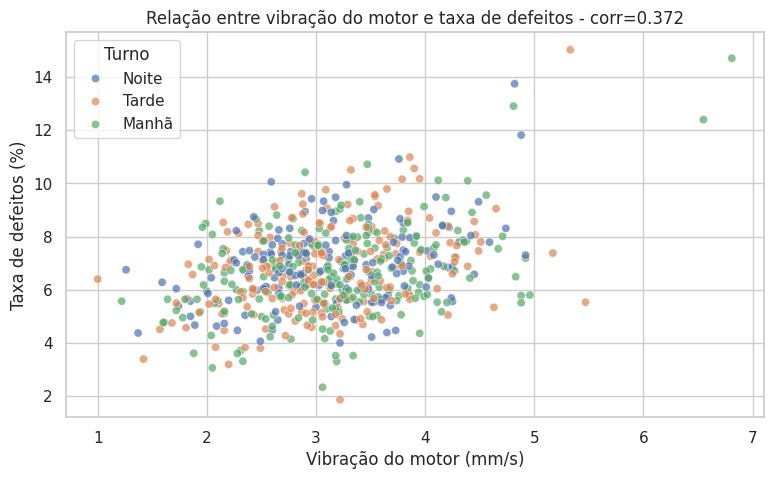

In [ ]:

# ------------------------------------------------------------
# 16) Scatter plot: vibração versus taxa de defeitos
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=dados,
    x="vibracao_motor_mm_s",
    y="taxa_defeitos_pct",
    hue="turno",
    alpha=0.7
)

corr = dados["vibracao_motor_mm_s"].corr(dados["taxa_defeitos_pct"]).round(3)

plt.title(f"Relação entre vibração do motor e taxa de defeitos - corr={corr}")
plt.xlabel("Vibração do motor (mm/s)")
plt.ylabel("Taxa de defeitos (%)")
plt.legend(title="Turno")
plt.show()



### Interpretação do scatter plot


Há uma **tendência positiva** entre vibração do motor e taxa de defeitos.

Ou seja:

> Quando a vibração do motor aumenta, a taxa de defeitos tende a aumentar.

Isso confirma visualmente a correlação positiva observada anteriormente entre essas variáveis.

## Região mais concentrada dos dados

A maior parte das observações está concentrada aproximadamente em:

```text id="n0zcq3"
vibração: entre 2 e 4.5 mm/s
taxa de defeitos: entre 4% e 9%
```

Essa parece ser a faixa normal de operação do processo.

Dentro dessa região, os pontos estão bastante espalhados. Isso indica que a vibração ajuda a explicar parte da variação da taxa de defeitos, mas não explica tudo sozinha.

## Pontos de atenção

Existem alguns pontos com vibração mais alta, acima de aproximadamente:

```text id="4zfh2e"
5 mm/s
```

Nesses casos, aparecem taxas de defeitos bem elevadas, próximas ou acima de:

```text id="bqzq89"
12% a 15%
```

Esses pontos podem representar situações anormais, como:

```text id="k10ed8"
desgaste mecânico
desalinhamento
folga em componentes
falha de manutenção
operação fora do regime ideal
```

Também aparecem alguns pontos com taxa de defeitos alta mesmo com vibração intermediária, indicando que outros fatores do processo também podem estar influenciando os defeitos.

## Comparação entre turnos

Visualmente, os três turnos estão bastante misturados. Isso sugere que o efeito da vibração sobre defeitos ocorre de forma relativamente parecida nos turnos `Manhã`, `Tarde` e `Noite`. Porém, alguns pontos extremos aparecem em diferentes turnos. Portanto, seria interessante calcular estatísticas por turno, por exemplo:

```python id="rj8u3r"
dados.groupby("turno")[["vibracao_motor_mm_s", "taxa_defeitos_pct"]].mean()
```

e também a correlação por turno:

```python id="y0uc5"
dados.groupby("turno").apply(
    lambda grupo: grupo["vibracao_motor_mm_s"].corr(grupo["taxa_defeitos_pct"])
)
```

## Conclusão

A figura sugere que a vibração do motor é uma variável relevante para monitorar a qualidade do processo. Em especial, valores mais altos de vibração estão associados a maiores taxas de defeitos.

Em um contexto industrial, essa análise poderia apoiar uma regra prática como:

> Monitorar períodos em que a vibração do motor ultrapassa determinado limite, pois eles podem estar associados a aumento da taxa de defeitos e necessidade de manutenção preventiva.



## 18. Scatter plot: desvio da temperatura versus taxa de defeitos

Agora vamos avaliar se afastamentos da temperatura ideal parecem estar relacionados à taxa de defeitos.

Usaremos:

- eixo X: `desvio_temperatura_c`;
- eixo Y: `taxa_defeitos_pct`;
- cor dos pontos: `maquina`.

Isso ajuda a investigar se alguma máquina apresenta comportamento diferente.


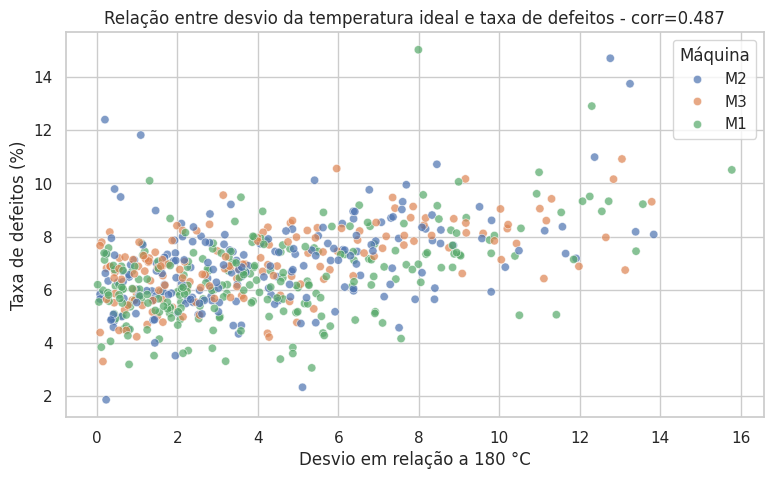

In [ ]:

# ------------------------------------------------------------
# 17) Scatter plot: desvio da temperatura versus taxa de defeitos
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=dados,
    x="desvio_temperatura_c",
    y="taxa_defeitos_pct",
    hue="maquina",
    alpha=0.7
)

corr = dados["desvio_temperatura_c"].corr(dados["taxa_defeitos_pct"]).round(3)

plt.title(f"Relação entre desvio da temperatura ideal e taxa de defeitos - corr={corr}")
plt.xlabel("Desvio em relação a 180 °C")
plt.ylabel("Taxa de defeitos (%)")
plt.legend(title="Máquina")
plt.show()



### Interpretação do segundo scatter plot

Há uma **correlação positiva moderada** entre o desvio em relação à temperatura ideal de `180 °C` e a taxa de defeitos.

Em termos práticos:

> Quanto maior o desvio da temperatura em relação ao valor ideal, maior tende a ser a taxa de defeitos.

Isso sugere que a **estabilidade térmica** é importante para a qualidade do processo.

## Região mais concentrada dos dados

A maior parte dos pontos está concentrada aproximadamente em:

```text id="yp82k1"
desvio de temperatura: entre 0 e 5 °C
taxa de defeitos: entre 4% e 8%
```

Essa parece ser a região mais comum de operação.

Quando o desvio de temperatura aumenta para valores acima de:

```text id="lvipy2"
8 °C a 10 °C
```

começam a aparecer mais casos com taxa de defeitos acima de:

```text id="jib610"
9% a 12%
```

Isso indica que desvios térmicos maiores podem estar associados a pior desempenho de qualidade.

## Pontos extremos

Há alguns pontos com desvio de temperatura elevado, próximos de:

```text id="h5vagt"
12 °C a 16 °C
```

e taxas de defeitos altas, algumas próximas de:

```text id="oz0w07"
13% a 15%
```

Esses pontos merecem atenção, pois podem representar períodos de instabilidade térmica, problemas de controle do forno, falhas de ajuste operacional ou condições anormais do processo.

Também existem alguns pontos com taxa de defeitos alta mesmo com baixo desvio de temperatura. Isso indica que a temperatura não é a única causa possível dos defeitos; outras variáveis, como vibração, velocidade da esteira, umidade, matéria-prima ou máquina utilizada, também podem influenciar.

## Comparação entre máquinas

As três máquinas aparecem bastante misturadas no gráfico. Não há uma separação visual muito clara indicando que uma máquina tenha sempre maior taxa de defeitos ou maior desvio térmico. Porém, alguns pontos extremos parecem aparecer em diferentes máquinas. Então seria útil comparar estatísticas por máquina, por exemplo:

```python id="cf9xsa"
dados.groupby("maquina")[["desvio_temperatura_c", "taxa_defeitos_pct"]].mean()
```

E também calcular a correlação separadamente por máquina:

```python id="i4kg74"
dados.groupby("maquina").apply(
    lambda grupo: grupo["desvio_temperatura_c"].corr(grupo["taxa_defeitos_pct"])
)
```

Isso ajudaria a verificar se a relação entre desvio térmico e defeitos é igual para `M1`, `M2` e `M3`, ou se alguma máquina é mais sensível à instabilidade térmica.

## Conclusão

A figura sugere que o **desvio em relação à temperatura ideal de 180 °C** é uma variável relevante para explicar a taxa de defeitos.

A correlação de `0.487` indica uma associação positiva moderada: maiores desvios térmicos tendem a estar associados a maiores taxas de defeitos.

Em um contexto industrial, isso poderia justificar uma regra prática como:

> Monitorar e reduzir desvios em relação à temperatura ideal, pois a instabilidade térmica parece estar associada ao aumento da taxa de defeitos.



## 19. Resumo por grupo com `groupby`

Além de analisar todos os dados juntos, é comum resumir os resultados por grupo.

Nesta célula, vamos calcular a média e a mediana da taxa de defeitos por máquina e por turno.

Principais recursos usados:

- `.groupby("coluna")`: agrupa os dados por uma categoria.
- `.agg(...)`: aplica várias estatísticas ao mesmo tempo.
- `.sort_values(...)`: ordena a tabela por uma coluna.


In [ ]:

# ------------------------------------------------------------
# 18) Resumo por máquina e por turno
# ------------------------------------------------------------

resumo_maquina = (
    dados
    .groupby("maquina")
    .agg(
        media_defeitos=("taxa_defeitos_pct", "mean"),
        mediana_defeitos=("taxa_defeitos_pct", "median"),
        media_vibracao=("vibracao_motor_mm_s", "mean"),
        quantidade_registros=("taxa_defeitos_pct", "count")
    )
    .sort_values("media_defeitos", ascending=False)
)

print("Resumo por máquina:")
display(resumo_maquina.round(3))

resumo_turno = (
    dados
    .groupby("turno")
    .agg(
        media_defeitos=("taxa_defeitos_pct", "mean"),
        mediana_defeitos=("taxa_defeitos_pct", "median"),
        media_vibracao=("vibracao_motor_mm_s", "mean"),
        quantidade_registros=("taxa_defeitos_pct", "count")
    )
    .sort_values("media_defeitos", ascending=False)
)

print("\nResumo por turno:")
display(resumo_turno.round(3))


Resumo por máquina:


,media_defeitos,mediana_defeitos,media_vibracao,quantidade_registros
maquina,,,,
M3,7.038,6.960,3.479,161
M2,6.937,6.850,3.196,199
M1,6.507,6.315,2.877,240



Resumo por turno:


,media_defeitos,mediana_defeitos,media_vibracao,quantidade_registros
turno,,,,
Noite,6.919,6.875,3.141,164
Tarde,6.791,6.810,3.090,207
Manhã,6.703,6.680,3.196,229



### Interpretação do resumo por grupo

O `groupby` permite comparar categorias.

Se uma máquina apresentar média de defeitos maior, isso pode sugerir necessidade de investigação. Porém, antes de concluir que a máquina é a causa do problema, seria necessário verificar outros fatores, como:

- tipo de produto processado;
- operador;
- turno;
- velocidade da linha;
- histórico de manutenção;
- condições ambientais.

Esse cuidado é essencial em análise de dados aplicada.



## 20. Atividade de consolidação

Agora que os principais conceitos foram apresentados, tente responder usando a base `dados`:

1. Qual variável numérica tem maior desvio padrão?
2. Qual variável parece ter maior obliquidade positiva?
3. Qual é o percentil 95 da taxa de defeitos?
4. Qual máquina apresenta maior média de vibração?
5. O heatmap sugere quais variáveis mais associadas à taxa de defeitos?
6. O scatter plot confirma visualmente essa associação?

Essas perguntas ajudam a conectar estatística descritiva com interpretação industrial.


In [ ]:

# ------------------------------------------------------------
# 19) Espaço para os alunos experimentarem
# ------------------------------------------------------------

# Dica 1:
# Para ver as colunas disponíveis:
print(dados.columns)

# Dica 2:
# Experimente adaptar os comandos abaixo.

# Exemplo: percentil 95 da taxa de defeitos
p95_defeitos = dados["taxa_defeitos_pct"].quantile(0.95)
print(f"\nP95 da taxa de defeitos: {p95_defeitos:.2f}%")

# Exemplo: máquina com maior média de vibração
media_vibracao_por_maquina = dados.groupby("maquina")["vibracao_motor_mm_s"].mean()
display(media_vibracao_por_maquina.sort_values(ascending=False))


Index(['data', 'turno', 'maquina', 'temperatura_forno_c', 'pressao_linha_bar',
       'velocidade_esteira_m_min', 'vibracao_motor_mm_s',
       'umidade_ambiente_pct', 'consumo_energia_kwh', 'tempo_ciclo_s',
       'taxa_defeitos_pct', 'desvio_temperatura_c'],
      dtype='object')

P95 da taxa de defeitos: 9.31%


,vibracao_motor_mm_s
maquina,
M3,3.479
M2,3.196
M1,2.877



## 21. Conclusão

Neste notebook, usamos uma base sintética de uma linha industrial para estudar conceitos fundamentais de análise exploratória de dados.

Aprendemos a calcular e interpretar:

- medidas de localização;
- medidas de espalhamento;
- medidas de formato da distribuição;
- correlações;
- heatmaps;
- scatter plots;
- resumos por grupo.

Essas etapas são importantes antes da construção de modelos de aprendizado de máquina, porque ajudam a entender os dados, identificar padrões, levantar hipóteses e detectar possíveis problemas de qualidade nos registros.

Em um fluxo completo de aprendizado de máquina, a próxima etapa poderia ser construir modelos para prever `taxa_defeitos_pct` ou classificar períodos de produção como “normais” ou “críticos”.
